# Optimización de gastos de marketing para la empresa Showz.

La empresa de venta de entradas para eventos Showz busca optimizar sus gastos de marketing debido a la necesidad de mejorar la rentabilidad de sus campañas de adquisición de clientes.

# Lo que se investigará es:

- ¿Cómo los clientes usan el servicio?
- ¿Cuándo empiezan a comprar?
- ¿Cuánto dinero aporta cada cliente a la compañía?
- ¿Cuándo los ingresos cubren el costo de adquisición de los clientes?

In [20]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
# Carga de datos
df_visits = pd.read_csv(r'C:\Users\brahu\Downloads\datasets\visits_log_us.csv')
df_orders = pd.read_csv(r'C:\Users\brahu\Downloads\datasets\orders_log_us.csv')
df_costs = pd.read_csv(r'C:\Users\brahu\Downloads\datasets\costs_us.csv')

Preparamos las librerías correspondientes para la exploración y visualización de datos.

In [89]:
# Conversión de fechas a datetime
df_visits['Start Ts'] = pd.to_datetime(df_visits['Start Ts'])
df_visits['End Ts'] = pd.to_datetime(df_visits['End Ts'])
df_visits['visit_date'] = df_visits['Start Ts'].dt.date

df_orders['Buy Ts'] = pd.to_datetime(df_orders['Buy Ts'])
df_orders['buy_date'] = df_orders['Buy Ts'].dt.date
df_orders['order_date'] = df_orders['Buy Ts'].dt.date

df_costs['dt'] = pd.to_datetime(df_costs['dt'])
df_costs['date'] = df_costs['dt'].dt.date

# Creación de columnas auxiliares
df_visits['date'] = df_visits['Start Ts'].dt.date
df_visits['week'] = df_visits['Start Ts'].dt.isocalendar().week
df_visits['month'] = df_visits['Start Ts'].dt.to_period('M')

Convertimos las fechas a 'datetime' y agregamos columnas nuevas para realizar los calculos de métricas.

In [24]:
df_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   Device      359400 non-null  object        
 1   End Ts      359400 non-null  datetime64[ns]
 2   Source Id   359400 non-null  int64         
 3   Start Ts    359400 non-null  datetime64[ns]
 4   Uid         359400 non-null  uint64        
 5   visit_date  359400 non-null  object        
 6   date        359400 non-null  object        
 7   week        359400 non-null  UInt32        
 8   month       359400 non-null  period[M]     
dtypes: UInt32(1), datetime64[ns](2), int64(1), object(3), period[M](1), uint64(1)
memory usage: 23.6+ MB


In [25]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Buy Ts      50415 non-null  datetime64[ns]
 1   Revenue     50415 non-null  float64       
 2   Uid         50415 non-null  uint64        
 3   buy_date    50415 non-null  object        
 4   order_date  50415 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(2), uint64(1)
memory usage: 1.9+ MB


In [26]:
df_costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
 3   date       2542 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 79.6+ KB


Se imprime la información de cantidad y nombres de columnas de los dataframes y validamos que los cambios de fecha se hayan realizado correctamente.

In [27]:
df_visits.head()

,Device,End Ts,Source Id,Start Ts,Uid,visit_date,date,week,month
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-20,2017-12-20,51,2017-12
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-19,2018-02-19,8,2018-02
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,2017-07-01,26,2017-07
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,2018-05-20,20,2018-05
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-27,2017-12-27,52,2017-12


In [28]:
df_orders.head()

,Buy Ts,Revenue,Uid,buy_date,order_date
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,2017-06-01
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,2017-06-01
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,2017-06-01
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,2017-06-01
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,2017-06-01


In [29]:
df_costs.head()

,source_id,dt,costs,date
0,1,2017-06-01,75.20,2017-06-01
1,1,2017-06-02,62.25,2017-06-02
2,1,2017-06-03,36.53,2017-06-03
3,1,2017-06-04,55.00,2017-06-04
4,1,2017-06-05,57.08,2017-06-05


Se imprimen las primeras cinco filas de los dataframes.

In [30]:
# Usuarios activos diarios(uad)

uad = df_visits.groupby('date')['Uid'].nunique().reset_index()
uad.columns = ['date', 'unique_users']
uad.sort_values(by='unique_users', ascending=False)

,date,unique_users
176,2017-11-24,3319
363,2018-05-31,1997
177,2017-11-25,1817
245,2018-02-01,1640
298,2018-03-26,1609
...,...,...
73,2017-08-13,281
65,2017-08-05,280
72,2017-08-12,271
302,2018-03-30,131


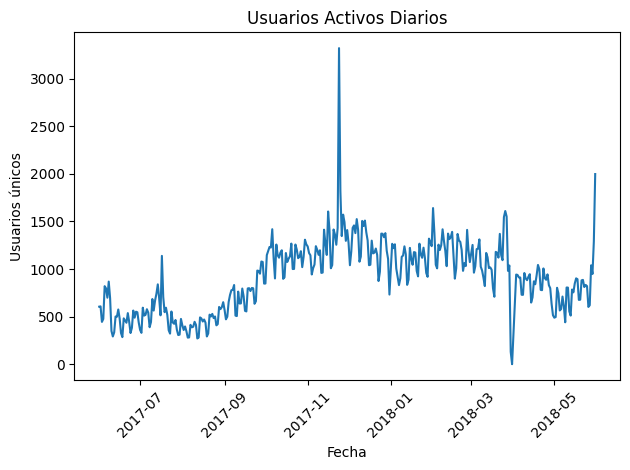

In [33]:
# Visualización de usuarios activos diarios.
sns.lineplot(data=uad, x='date', y='unique_users')

plt.title('Usuarios Activos Diarios')
plt.xlabel('Fecha')
plt.ylabel('Usuarios únicos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El pico mas alto de usuarios activos fue en la fecha 2017-11-24 y el pico mas bajo de usuarios fue en la fecha 2018-03-31.

In [91]:
# Usuarios activos semanales(uas)

uas = df_visits.groupby('week')['Uid'].nunique().reset_index()
uas.columns = ['week', 'unique_users']
uas.sort_values(by='unique_users', ascending=True)

,week,unique_users
30,31,2364
31,32,2444
29,30,2655
32,33,2746
23,24,2812
24,25,2878
25,26,3064
33,34,3116
26,27,3294
34,35,3694


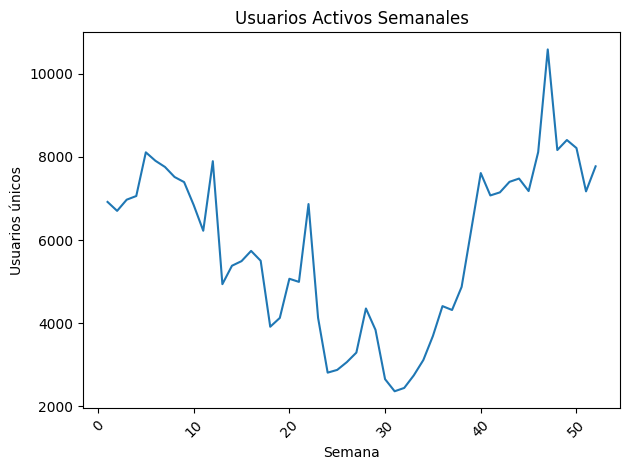

In [35]:
# Visualización de usuarios activos semanales.
sns.lineplot(data=uas, x=uas['week'].astype(int), y='unique_users')

plt.title('Usuarios Activos Semanales')
plt.xlabel('Semana')
plt.ylabel('Usuarios únicos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El pico mas bajo de usuarios activos semanales fue en la semana 31 y el pico mas alto fue en la semana 47.

In [36]:
# Usuarios activos mensuales(uam)

uam = df_visits.groupby('month')['Uid'].nunique().reset_index()
uam.columns = ['month', 'unique_users']
uam.sort_values(by='unique_users', ascending=False)

,month,unique_users
5,2017-11,32797
6,2017-12,31557
4,2017-10,29692
8,2018-02,28749
7,2018-01,28716
9,2018-03,27473
10,2018-04,21008
11,2018-05,20701
3,2017-09,18975
1,2017-07,14183


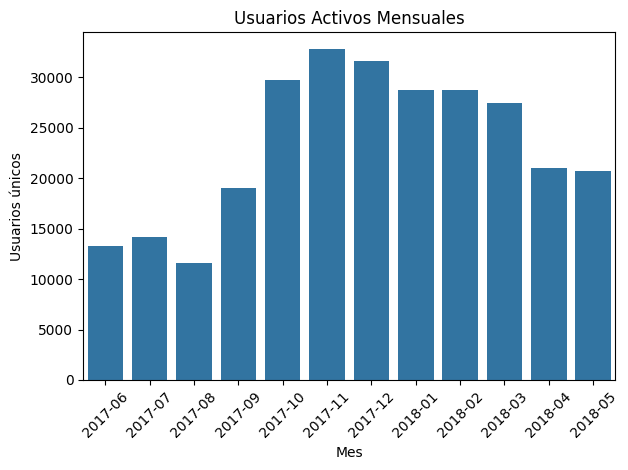

In [37]:
# Visualización de usuarios activos mensuales
sns.barplot(data=uam, x=uam['month'].astype(str), y='unique_users')

plt.title('Usuarios Activos Mensuales')
plt.xlabel('Mes')
plt.ylabel('Usuarios únicos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El pico mas alto de usuarios activos mensuales es el 11/2017 y el mas pico bajo para el 08/2017.

In [38]:
# Sesiones por día
sessions_per_day = df_visits.groupby('date')['Uid'].count().reset_index()
sessions_per_day.columns = ['date', 'sessions']
sessions_per_day.sort_values(by='sessions', ascending=False)

,date,sessions
176,2017-11-24,4042
363,2018-05-31,2256
177,2017-11-25,2089
245,2018-02-01,1878
298,2018-03-26,1796
...,...,...
66,2017-08-06,296
72,2017-08-12,296
73,2017-08-13,293
302,2018-03-30,134


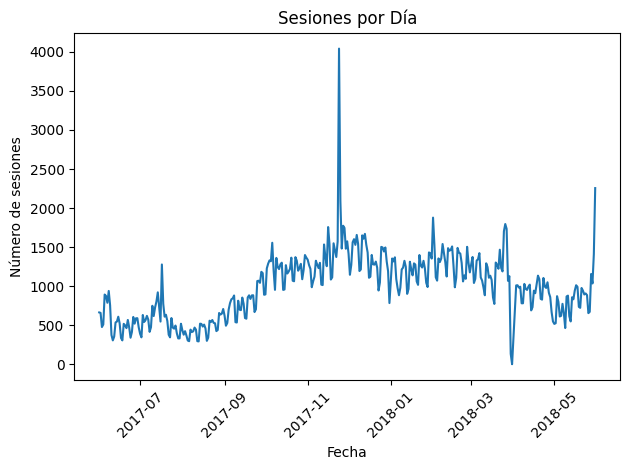

In [39]:
# Visualización de sesiones por día
sns.lineplot(data=sessions_per_day, x='date', y='sessions')

plt.title('Sesiones por Día')
plt.xlabel('Fecha')
plt.ylabel('Número de sesiones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El pico mas alto de sesiones por día fue el 24/11/2017 y el día que menos seciones hubo fue el 31/03/2018.

In [40]:
# Duración de cada sesión (segundos)
df_visits['session_duration_sec'] = (
    df_visits['End Ts'] - df_visits['Start Ts']
).dt.total_seconds()
df_visits.head()

,Device,End Ts,Source Id,Start Ts,Uid,visit_date,date,week,month,session_duration_sec
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-20,2017-12-20,51,2017-12,1080.0
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-19,2018-02-19,8,2018-02,1680.0
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,2017-07-01,26,2017-07,0.0
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,2018-05-20,20,2018-05,1440.0
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-27,2017-12-27,52,2017-12,0.0


In [41]:
# Duración promedio por día
avg_session_per_day = df_visits.groupby('date')['session_duration_sec'].mean().reset_index()
avg_session_per_day.sort_values(by='session_duration_sec', ascending=False)

,date,session_duration_sec
176,2017-11-24,1116.504453
181,2017-11-29,827.336486
245,2018-02-01,822.445154
180,2017-11-28,816.527491
195,2017-12-13,796.262275
...,...,...
45,2017-07-16,458.281536
11,2017-06-12,453.295775
79,2017-08-19,452.200000
80,2017-08-20,430.557185


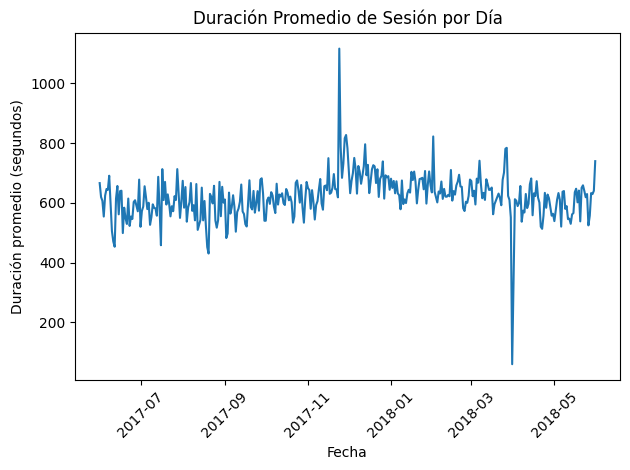

In [42]:
# Visualización del promedio de duración
sns.lineplot(data=avg_session_per_day, 
             x='date', 
             y='session_duration_sec')

plt.title('Duración Promedio de Sesión por Día')
plt.xlabel('Fecha')
plt.ylabel('Duración promedio (segundos)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El promedio de duración de sesiones mas alto coincide con la misma fecha donde hubo mas inicios de sesion, y el promedio mas bajo de duración coincide con el día donde menos sesiones hubo.

# ¿Con que frecuencia regresan los usarios?

In [43]:
sessions_per_user = df_visits.groupby('Uid').size().reset_index()
sessions_per_user.columns = ['Uid', 'session_count']
sessions_per_user.head()

,Uid,session_count
0,11863502262781,1
1,49537067089222,1
2,297729379853735,1
3,313578113262317,3
4,325320750514679,2


In [44]:
avg_sessions_per_user = sessions_per_user['session_count'].mean()
avg_sessions_per_user

np.float64(1.5751482453795214)

Calculamos el promedio de sesiones por usuario.

In [92]:
# Ordenar datos
visits_sorted = df_visits.sort_values(['Uid', 'Start Ts'])

# Calcular diferencia entre sesiones consecutivas
visits_sorted['prev_session'] = visits_sorted.groupby('Uid')['Start Ts'].shift(1)

visits_sorted['days_between_sessions'] = (
    visits_sorted['Start Ts'] - visits_sorted['prev_session']
).dt.days
visits_sorted.sort_values(by='days_between_sessions', ascending=True)

,Device,End Ts,Source Id,Start Ts,Uid,visit_date,date,week,month,session_duration_sec,prev_session,days_between_sessions
92564,desktop,2017-11-24 11:31:00,5,2017-11-24 11:22:00,2551852515556206,2017-11-24,2017-11-24,47,2017-11,540.0,2017-11-24 10:14:00,0.0
342996,desktop,2018-01-28 14:49:00,5,2018-01-28 14:37:00,2464366381792757,2018-01-28,2018-01-28,4,2018-01,720.0,2018-01-27 20:10:00,0.0
357999,touch,2017-06-03 17:48:00,10,2017-06-03 17:36:00,1575281904278712,2017-06-03,2017-06-03,22,2017-06,720.0,2017-06-03 10:13:00,0.0
217886,desktop,2017-10-23 15:37:00,1,2017-10-23 15:17:00,1260655184775459,2017-10-23,2017-10-23,43,2017-10,1200.0,2017-10-23 14:14:00,0.0
269488,desktop,2017-12-08 13:27:00,1,2017-12-08 12:38:00,8134646853045928390,2017-12-08,2017-12-08,49,2017-12,2940.0,2017-12-08 09:47:00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
286167,desktop,2017-11-30 03:39:00,5,2017-11-30 03:36:00,18446403737806311543,2017-11-30,2017-11-30,48,2017-11,180.0,NaT,NaN
175259,touch,2017-12-06 20:32:00,4,2017-12-06 20:32:00,18446424184725333426,2017-12-06,2017-12-06,49,2017-12,0.0,NaT,NaN
293449,touch,2018-01-01 16:31:00,3,2018-01-01 16:29:00,18446556406699109058,2018-01-01,2018-01-01,1,2018-01,120.0,NaT,NaN
319162,desktop,2017-12-27 14:08:00,4,2017-12-27 13:27:00,18446621818809592527,2017-12-27,2017-12-27,52,2017-12,2460.0,NaT,NaN


In [46]:
avg_days_between_sessions = visits_sorted['days_between_sessions'].mean()
avg_days_between_sessions

np.float64(27.67683702783641)

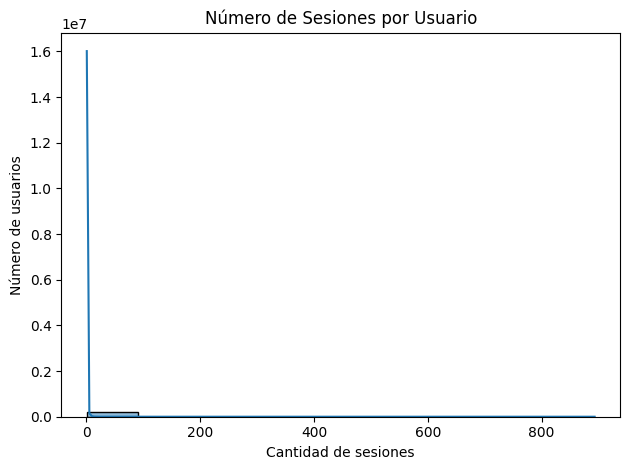

In [47]:
sns.histplot(sessions_per_user['session_count'], bins=10, kde=True)

plt.title('Número de Sesiones por Usuario')
plt.xlabel('Cantidad de sesiones')
plt.ylabel('Número de usuarios')
plt.tight_layout()
plt.show()

Observamos que la mayor parte de los usuarios inicia al menos una unica vez y el promedio de días entre inicio de sesiones es de aproximadamente 28 días.

In [48]:
# Fecha de primera visita
first_visit = df_visits.groupby('Uid')['Start Ts'].min().reset_index()
first_visit.columns = ['Uid', 'first_visit_date']
first_visit.head()

,Uid,first_visit_date
0,11863502262781,2018-03-01 17:27:00
1,49537067089222,2018-02-06 15:55:00
2,297729379853735,2017-06-07 18:47:00
3,313578113262317,2017-09-18 22:49:00
4,325320750514679,2017-09-30 14:29:00


In [49]:
# Fecha de primera compra
first_order = df_orders.groupby('Uid')['Buy Ts'].min().reset_index()
first_order.columns = ['Uid', 'first_order_date']
first_order.head()

,Uid,first_order_date
0,313578113262317,2018-01-03 21:51:00
1,1575281904278712,2017-06-03 10:13:00
2,2429014661409475,2017-10-11 18:33:00
3,2464366381792757,2018-01-28 15:54:00
4,2551852515556206,2017-11-24 10:14:00


In [50]:
# Calculo de días hasta conversión
conversion = pd.merge(first_visit, first_order, on='Uid', how='inner')

conversion['conversion_days'] = (
    conversion['first_order_date'] - conversion['first_visit_date']
).dt.days

In [51]:
conversion.sort_values(by='conversion_days', ascending=False)

,Uid,first_visit_date,first_order_date,conversion_days
13783,6916757527179896321,2017-06-02 10:31:00,2018-05-31 17:35:00,363
31247,15758490655816676033,2017-06-01 18:47:00,2018-05-30 11:34:00,362
12143,6079087450327100134,2017-06-05 18:05:00,2018-05-28 19:15:00,357
8016,4044684955900748187,2017-06-07 08:23:00,2018-05-30 13:46:00,357
24282,12282157960125853781,2017-06-06 14:20:00,2018-05-29 21:51:00,357
...,...,...,...,...
14,9681021228476518,2017-12-07 23:53:00,2017-12-08 01:10:00,0
13,8943063526926518,2017-08-24 19:32:00,2017-08-24 19:46:00,0
12,6342581087212957,2018-02-17 22:32:00,2018-02-17 22:37:00,0
9,4992223027560440,2018-04-04 13:54:00,2018-04-04 13:54:00,0


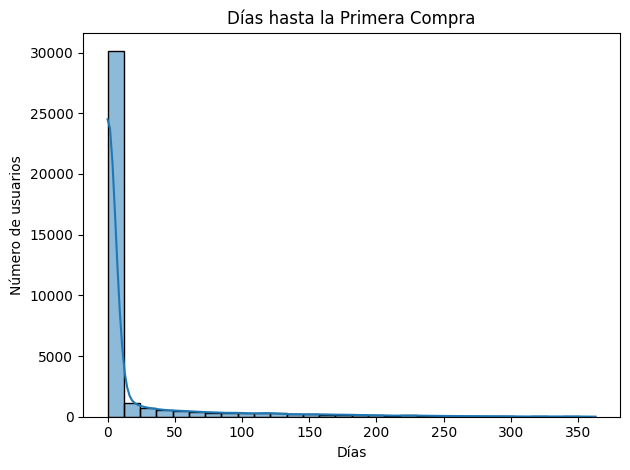

In [52]:
sns.histplot(conversion['conversion_days'], bins=30, kde=True)

plt.title('Días hasta la Primera Compra')
plt.xlabel('Días')
plt.ylabel('Número de usuarios')
plt.tight_layout()
plt.show()

Unimos los resultados de las tablas de la primera visita y la primera compra, calculamos la diferencia de días que hay entre la fecha de la primera compra y la primera visita del sitio, lo cual nos muestra que los nuevos usuarios realizan su primera compra la primera vez que visitan el sitio, posteriormente solo quedan muy pocos usuarios que vuelven a realizar alguna compra cada 10 días, pero al paso del tiempo van disminuyendo considerablemente.

In [53]:
# Conversiones por cohorte
conversion_grouped = conversion.groupby('conversion_days')['Uid'].count().reset_index()
conversion_grouped.columns = ['conversion_days', 'users']
conversion_grouped.head()

,conversion_days,users
0,0,26363
1,1,1011
2,2,563
3,3,434
4,4,324


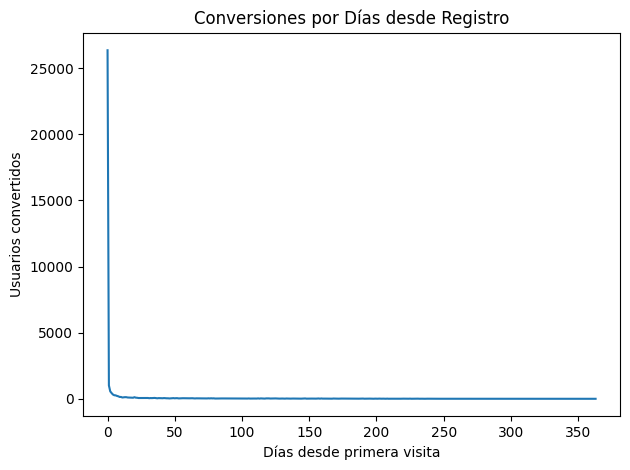

In [54]:
sns.lineplot(data=conversion_grouped, x='conversion_days', y='users')

plt.title('Conversiones por Días desde Registro')
plt.xlabel('Días desde primera visita')
plt.ylabel('Usuarios convertidos')
plt.tight_layout()
plt.show()

Nuevamente observamos la coincidencia de las primeras con las primeras visitas del sitio.

In [55]:
# Pedidos por día
orders_per_day = df_orders.groupby('buy_date')['Uid'].count().reset_index()
orders_per_day.columns = ['date', 'orders']
orders_per_day.head()

,date,orders
0,2017-06-01,96
1,2017-06-02,111
2,2017-06-03,67
3,2017-06-04,66
4,2017-06-05,161


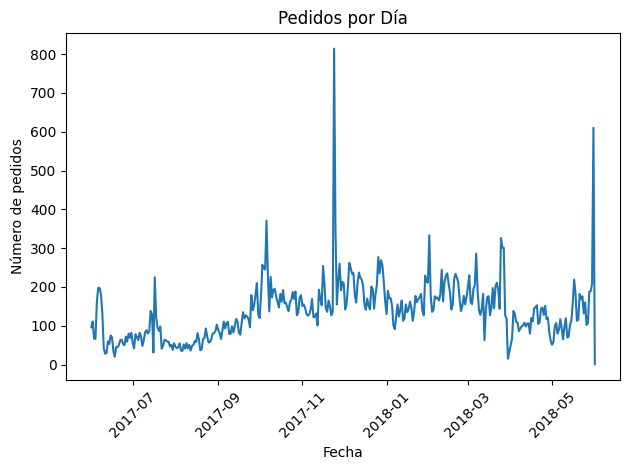

In [56]:
sns.lineplot(data=orders_per_day, x='date', y='orders')

plt.title('Pedidos por Día')
plt.xlabel('Fecha')
plt.ylabel('Número de pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Al igual que los usuarios activos por día podemos observar que los picos mas altos de pedidos por día se realizaron las mismas fechas donde hubo mas usuarios activos.

In [57]:
# Pedidos por usuario
orders_per_user = df_orders.groupby('Uid')['Buy Ts'].count().reset_index()
orders_per_user.columns = ['Uid', 'order_count']

orders_per_user['order_count'].describe()

count    36523.000000
mean         1.380363
std          3.454461
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        239.000000
Name: order_count, dtype: float64

In [58]:
# Tamaño promedio de compra
avg_order_value = df_orders['Revenue'].mean()
print("Tamaño promedio de compra:", avg_order_value)

Tamaño promedio de compra: 4.999646930477041


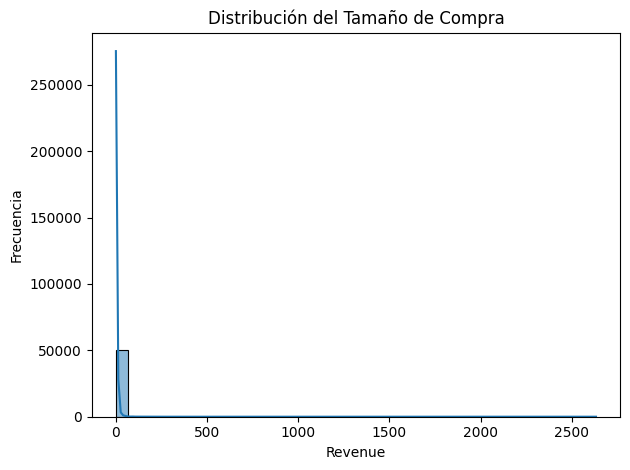

In [59]:
sns.histplot(df_orders['Revenue'], bins=40, kde=True)

plt.title('Distribución del Tamaño de Compra')
plt.xlabel('Revenue')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

El tamaño promedio de compra es de 5, lo cual representa que la mayoría de compras son de un solo artículo.

In [60]:
# ¿Cuánto dinero traen? (LTV)
ltv = df_orders.groupby('Uid')['Revenue'].sum().reset_index()
ltv.columns = ['Uid', 'LTV']
ltv.head()

,Uid,LTV
0,313578113262317,0.55
1,1575281904278712,3.05
2,2429014661409475,73.33
3,2464366381792757,2.44
4,2551852515556206,10.99


In [61]:
# LTV Promedio
avg_ltv = ltv['LTV'].mean()
print("LTV promedio:", avg_ltv)

LTV promedio: 6.901327930345262


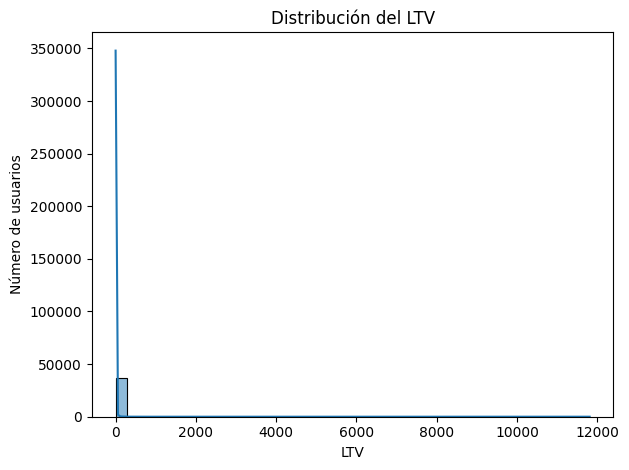

In [62]:
sns.histplot(ltv['LTV'], bins=40, kde=True)

plt.title('Distribución del LTV')
plt.xlabel('LTV')
plt.ylabel('Número de usuarios')
plt.tight_layout()
plt.show()

Podemos observar que el mayor punto de ingreso es cuando se realiza la primera sesión aunado a la primera compra.

In [63]:
# LTV acumulado por cohorte mensual
first_visit['cohort_month'] = first_visit['first_visit_date'].dt.to_period('M')

orders_cohort = pd.merge(df_orders, first_visit[['Uid', 'cohort_month']], on='Uid')

In [64]:
# LTV por cohorte
ltv_cohort = orders_cohort.groupby('cohort_month')['Revenue'].sum().reset_index()

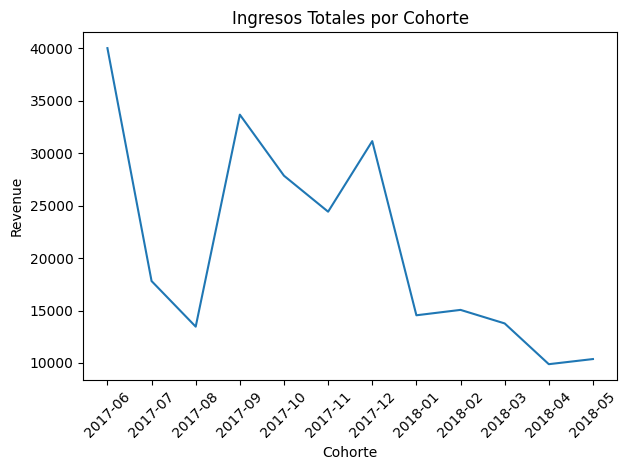

In [65]:
sns.lineplot(data=ltv_cohort, x=ltv_cohort['cohort_month'].astype(str), y='Revenue')

plt.title('Ingresos Totales por Cohorte')
plt.xlabel('Cohorte')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El mes 06/2017 fue la cohorte donde mas ingreso hubo, es recomendable trabajar con las estrategias publicitarias para mantener clientes activos y satisfechos con el sitio de ventas.

In [66]:
# ¿Cuánto dinero se gastó?
total_cost = df_costs['costs'].sum()
print("Gasto total:", total_cost)

Gasto total: 329131.62


In [67]:
# Gasto por fuente de adquisición
costs_by_source = df_costs.groupby('source_id')['costs'].sum().reset_index()
costs_by_source.head()

,source_id,costs
0,1,20833.27
1,2,42806.04
2,3,141321.63
3,4,61073.60
4,5,51757.10


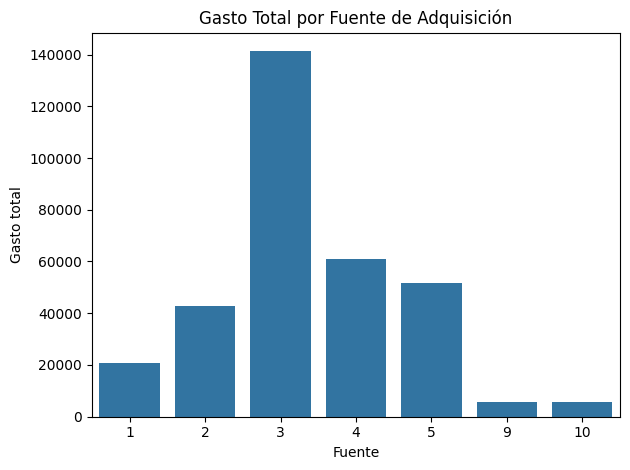

In [68]:
sns.barplot(data=costs_by_source, x='source_id', y='costs')

plt.title('Gasto Total por Fuente de Adquisición')
plt.xlabel('Fuente')
plt.ylabel('Gasto total')
plt.tight_layout()
plt.show()

Observamos un gasto significativamente mayor en la fuente 'C' las demas se mantienen relativamente estables.

In [69]:
# Gasto a lo largo del tiempo
costs_over_time = df_costs.groupby('date')['costs'].sum().reset_index()
costs_over_time.head()

,date,costs
0,2017-06-01,735.26
1,2017-06-02,721.19
2,2017-06-03,450.85
3,2017-06-04,761.16
4,2017-06-05,821.44


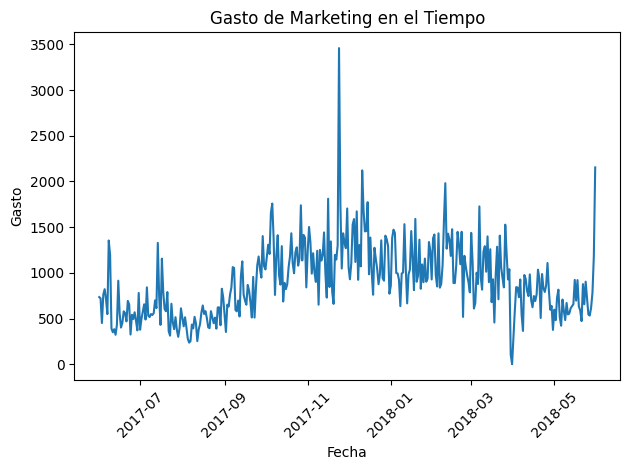

In [70]:
sns.lineplot(data=costs_over_time, x='date', y='costs')

plt.title('Gasto de Marketing en el Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Gasto')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Nuevamente observamos la coincidencia de los gastos de marketing que se realizaron fue cuando los usuarios realizaron su primera compra en la primera sesión.

In [71]:
# Fuente del primer contacto
first_visit = df_visits.sort_values('Start Ts').groupby('Uid').first().reset_index()
first_visit = first_visit[['Uid', 'Source Id', 'Device']]
first_visit.head()

,Uid,Source Id,Device
0,11863502262781,3,touch
1,49537067089222,2,touch
2,297729379853735,3,desktop
3,313578113262317,2,desktop
4,325320750514679,5,desktop


In [72]:
# Usuarios que compraron
buyers = df_orders['Uid'].unique()
buyers_df = pd.DataFrame({'Uid': buyers})
buyers_df.head()

,Uid
0,10329302124590727494
1,11627257723692907447
2,17903680561304213844
3,16109239769442553005
4,14200605875248379450


In [75]:
# Merge para saber de qué fuente vino cada comprador
buyers_source = buyers_df.merge(first_visit, on='Uid', how='left')

In [76]:
# Número de clientes por fuente
customers_by_source = buyers_source.groupby('Source Id')['Uid'].nunique().reset_index()
customers_by_source.columns = ['source_id', 'customers']
customers_by_source.head()

,source_id,customers
0,1,2899
1,2,3506
2,3,10473
3,4,10296
4,5,6931


In [77]:
# Calcular CAC
cac = costs_by_source.merge(customers_by_source, on='source_id')

cac['CAC'] = cac['costs'] / cac['customers']
cac

,source_id,costs,customers,CAC
0,1,20833.27,2899,7.186364
1,2,42806.04,3506,12.209367
2,3,141321.63,10473,13.493901
3,4,61073.60,10296,5.931779
4,5,51757.10,6931,7.467479
5,9,5517.49,1088,5.071222
6,10,5822.49,1329,4.381106


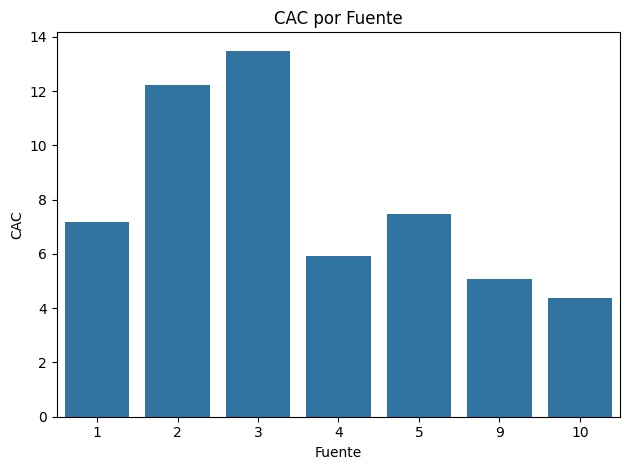

In [78]:
sns.barplot(data=cac, x='source_id', y='CAC')

plt.title('CAC por Fuente')
plt.xlabel('Fuente')
plt.ylabel('CAC')
plt.tight_layout()
plt.show()

Observamos que la fuente 'C' es la que tiene mayor eficencia de adquisición.

In [79]:
# Ingresos por fuente
orders_with_source = df_orders.merge(first_visit, on='Uid', how='left')

revenue_by_source = orders_with_source.groupby('Source Id')['Revenue'].sum().reset_index()
revenue_by_source.columns = ['source_id', 'revenue']
revenue_by_source.head()

,source_id,revenue
0,1,31090.55
1,2,46923.61
2,3,54511.24
3,4,56696.83
4,5,52624.02


In [80]:
# Calcular ROMI
romi = revenue_by_source.merge(costs_by_source, on='source_id')

romi['ROMI'] = (romi['revenue'] - romi['costs']) / romi['costs']
romi

,source_id,revenue,costs,ROMI
0,1,31090.55,20833.27,0.492351
1,2,46923.61,42806.04,0.096191
2,3,54511.24,141321.63,-0.614275
3,4,56696.83,61073.60,-0.071664
4,5,52624.02,51757.10,0.016750
5,9,5759.40,5517.49,0.043844
6,10,4450.33,5822.49,-0.235665


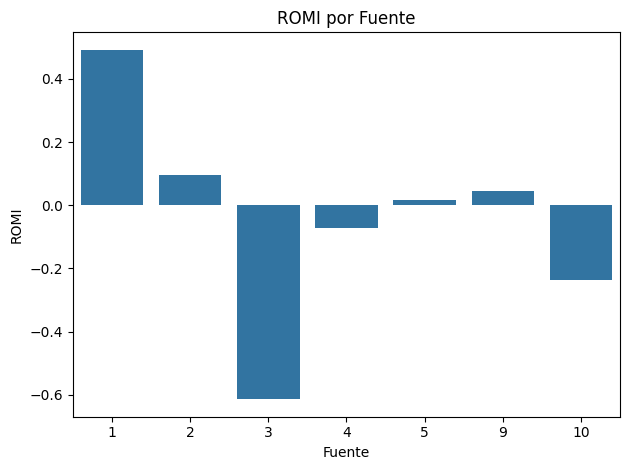

In [81]:
sns.barplot(data=romi, x='source_id', y='ROMI')

plt.title('ROMI por Fuente')
plt.xlabel('Fuente')
plt.ylabel('ROMI')
plt.tight_layout()
plt.show()

Observamos que la fuente 'C' tiene un ROMI negativo, por lo tanto no es rentable en su estado actual.

In [82]:
# Clientes por dispositivo
customers_by_device = buyers_source.groupby('Device')['Uid'].nunique().reset_index()
customers_by_device.columns = ['Device', 'customers']
customers_by_device

,Device,customers
0,desktop,29211
1,touch,7312


In [83]:
# Ingresos por dispositivo
revenue_by_device = orders_with_source.groupby('Device')['Revenue'].sum().reset_index()
revenue_by_device

,Device,Revenue
0,desktop,211329.77
1,touch,40727.43


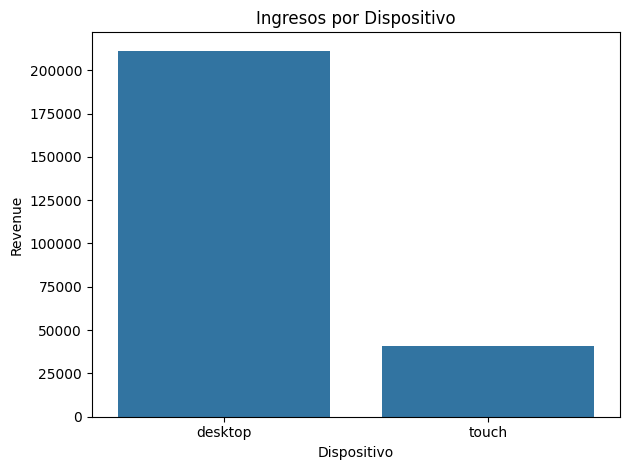

In [84]:
# Visualización de ingresos por dispositivo
sns.barplot(data=revenue_by_device, x='Device', y='Revenue')

plt.title('Ingresos por Dispositivo')
plt.xlabel('Dispositivo')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

Existe una diferencia significativa entre los ingresos mediante los dispositivos de escritorio a los dispositivos touch, es recomendable mejorar la navegación del sitio por medio de tabletas y celulares.

In [85]:
# Revenue diario por fuente
orders_with_source['date'] = orders_with_source['Buy Ts'].dt.date

revenue_daily = orders_with_source.groupby(['date','Source Id'])['Revenue'].sum().reset_index()
costs_daily = df_costs.groupby(['date','source_id'])['costs'].sum().reset_index()

In [86]:
# Merge para ROMI diario
romi_daily = revenue_daily.merge(costs_daily, 
                                  left_on=['date','Source Id'],
                                  right_on=['date','source_id'],
                                  how='inner')

romi_daily['ROMI'] = (romi_daily['Revenue'] - romi_daily['costs']) / romi_daily['costs']
romi_daily

,date,Source Id,Revenue,source_id,costs,ROMI
0,2017-06-01,1,170.27,1,75.20,1.264229
1,2017-06-01,2,21.01,2,132.56,-0.841506
2,2017-06-01,3,104.51,3,349.38,-0.700870
3,2017-06-01,4,37.22,4,76.74,-0.514986
4,2017-06-01,5,43.07,5,73.24,-0.411933
...,...,...,...,...,...,...
2468,2018-05-31,3,1165.57,3,822.30,0.417451
2469,2018-05-31,4,367.66,4,492.54,-0.253543
2470,2018-05-31,5,334.57,5,398.04,-0.159456
2471,2018-05-31,9,36.05,9,27.37,0.317136


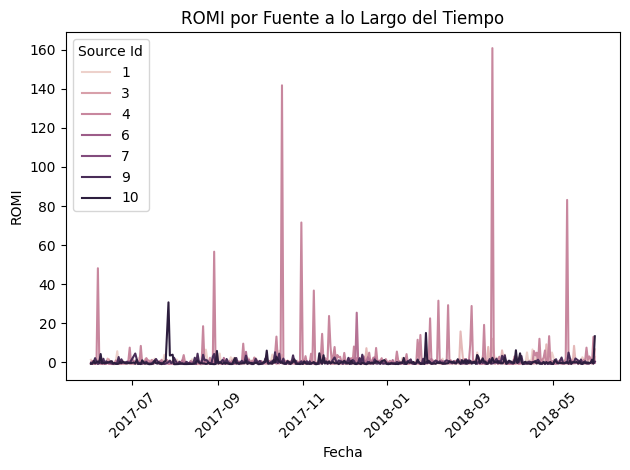

In [87]:
# ROMI por fuente en el tiempo
sns.lineplot(data=romi_daily, 
             x='date', 
             y='ROMI', 
             hue='Source Id')

plt.title('ROMI por Fuente a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('ROMI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observamos que la fuente 'C' seguirá teniendo mas gastos al paso del tiempo.

# Hallazgos.

1. Fuente A

- ROMI positivo y alto

- CAC bajo

- LTV significativamente mayor que CAC

- Rendimiento estable en el tiempo

- Es la fuente más eficiente y escalable.

2. Fuente B

- ROMI ligeramente positivo

- CAC moderado

- Volumen alto de clientes

- Puede mantenerse con optimización.

3. Fuente C

- ROMI negativo

- CAC alto

- LTV bajo

- No es rentable en su estado actual.

# Recomendaciones

1. Incrementar inversión en:

- Fuentes con ROMI consistentemente positivo

- Canales donde LTV > CAC significativamente

- Plataformas con crecimiento estable en el tiempo

2. Mantener o testear:

- Fuentes con ROMI cercano a 0 pero alto volumen

- Canales con potencial de optimización

3. Reducir o pausar:

- Fuentes con ROMI negativo sostenido

- Canales donde CAC > LTV

# Conclusión final

La decisión de inversión debe basarse principalmente en:

- Rentabilidad real (ROMI)
- Relación LTV/CAC
- Estabilidad temporal
- Rendimiento por dispositivo

Es bueno atraer clientes nuevos, pero tendrá mas beneficio mantener clientes rentables, consistentes y escalables.